# Maps I: Basic Maps

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import csv
from collections import Counter

In [5]:
import matplotlib, cartopy
print(matplotlib.__version__)
print(cartopy.__version__)


#if you see mismatched versions because cartopy is too old, like below:
#
#3.7.5
#0.18.0
#
# run code below in terminal to create a new base
# conda create -n cartomap -c conda-forge python=3.10 cartopy matplotlib
# conda install -n cartomap -c conda-forge jupyter
# conda activate cartomap
# this works in my case when the base environment is too old for new cartopy versions, but then each time when plotting map, need to 
# activate the new environment in the terminal first:
#
# conda activate cartomap
# jupyter notebook


3.10.8
0.25.0


In [6]:
import warnings

# Hide Shapely geometry warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="shapely")

# Hide numpy RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")

# Hide CJK font warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.text")

# Hide Cartopy warnings
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

# 2. Read in Data

In [7]:
D=[]
n=0
#flight information
ad='routes.csv'
with open(ad, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for line in reader:
            D.append(line)

In [17]:
len(D)

66380

In [48]:
D

[['airline_iata',
  'airline_name',
  'airline_country',
  'src_iata',
  'src_airport',
  'src_city',
  'src_country',
  'src_lat',
  'src_lon',
  'dst_iata',
  'dst_airport',
  'dst_city',
  'dst_country',
  'dst_lat',
  'dst_lon',
  'codeshare',
  'stops',
  'equipment',
  'distance_km'],
 ['2B',
  'Aerocondor',
  'Portugal',
  'AER',
  'Sochi International Airport',
  'Sochi',
  'RU',
  '43.449902',
  '39.9566',
  'KZN',
  'Kazan International Airport',
  'Kazan',
  'RU',
  '55.606201',
  '49.278702',
  '',
  '0',
  'CR2',
  '1507'],
 ['2B',
  'Aerocondor',
  'Portugal',
  'ASF',
  'Astrakhan Narimanovo Boris M. Kustodiev International Airport',
  'Astrakhan',
  'RU',
  '46.282843',
  '48.010511',
  'KZN',
  'Kazan International Airport',
  'Kazan',
  'RU',
  '55.606201',
  '49.278702',
  '',
  '0',
  'CR2',
  '1040'],
 ['2B',
  'Aerocondor',
  'Portugal',
  'ASF',
  'Astrakhan Narimanovo Boris M. Kustodiev International Airport',
  'Astrakhan',
  'RU',
  '46.282843',
  '48.010511',

In [8]:
#nodes
airports = {}
#edges
routes = []
for i in D[1:]:
    src_iata =i[3]
    src_lat=float(i[7])
    src_lon=float(i[8])
    dst_iata=i[9]
    dst_lat = float(i[13])
    dst_lon = float(i[14])
    airports[src_iata] = (src_lat,src_lon)
    airports[dst_iata] = (dst_lat,dst_lon)
    routes.append((src_iata,dst_iata))

In [53]:
routes

[('AER', 'KZN'),
 ('ASF', 'KZN'),
 ('ASF', 'MRV'),
 ('CEK', 'KZN'),
 ('CEK', 'OVB'),
 ('DME', 'KZN'),
 ('DME', 'NBC'),
 ('DME', 'TGK'),
 ('DME', 'UUA'),
 ('EGO', 'KGD'),
 ('EGO', 'KZN'),
 ('GYD', 'NBC'),
 ('KGD', 'EGO'),
 ('KZN', 'AER'),
 ('KZN', 'ASF'),
 ('KZN', 'CEK'),
 ('KZN', 'DME'),
 ('KZN', 'EGO'),
 ('KZN', 'LED'),
 ('KZN', 'SVX'),
 ('LED', 'KZN'),
 ('LED', 'NBC'),
 ('LED', 'UUA'),
 ('MRV', 'ASF'),
 ('NBC', 'DME'),
 ('NBC', 'GYD'),
 ('NBC', 'LED'),
 ('NBC', 'SVX'),
 ('NJC', 'SVX'),
 ('NJC', 'UUA'),
 ('NUX', 'SVX'),
 ('OVB', 'CEK'),
 ('OVB', 'SVX'),
 ('SVX', 'KZN'),
 ('SVX', 'NBC'),
 ('SVX', 'NJC'),
 ('SVX', 'NUX'),
 ('SVX', 'OVB'),
 ('TGK', 'DME'),
 ('UUA', 'DME'),
 ('UUA', 'LED'),
 ('UUA', 'NJC'),
 ('BTK', 'IKT'),
 ('BTK', 'OVB'),
 ('CEK', 'OVB'),
 ('HTA', 'IKT'),
 ('IKT', 'BTK'),
 ('IKT', 'HTA'),
 ('IKT', 'KCK'),
 ('IKT', 'ODO'),
 ('IKT', 'OVB'),
 ('IKT', 'UKX'),
 ('IKT', 'ULK'),
 ('IKT', 'YKS'),
 ('KCK', 'IKT'),
 ('MJZ', 'OVB'),
 ('ODO', 'IKT'),
 ('OVB', 'BTK'),
 ('OVB', 'CEK'

In [54]:
airports

{'AER': (43.449902, 39.9566),
 'KZN': (55.606201, 49.278702),
 'ASF': (46.282843, 48.010511),
 'MRV': (44.225101, 43.081902),
 'CEK': (55.303141, 61.504927),
 'OVB': (55.019756, 82.618675),
 'DME': (55.408798, 37.9063),
 'NBC': (55.564701, 52.092499),
 'TGK': (47.1983333, 38.8491667),
 'UUA': (54.641184, 52.800229),
 'EGO': (50.643798828125, 36.5900993347168),
 'KGD': (54.89161, 20.598559),
 'GYD': (40.47278, 50.050931),
 'LED': (59.800301, 30.262501),
 'SVX': (56.743099212646, 60.802700042725),
 'NJC': (60.949299, 76.483597),
 'NUX': (66.06939697265625, 76.52030181884766),
 'BTK': (56.3696, 101.701822),
 'IKT': (52.266707, 104.395563),
 'HTA': (52.024841, 113.305839),
 'KCK': (57.773, 108.064),
 'ODO': (57.866100311299995, 114.242996216),
 'UKX': (56.856701, 105.730003),
 'ULK': (60.7206001282, 114.825996399),
 'YKS': (62.0933, 129.770996),
 'MJZ': (62.534698486328125, 114.03900146484375),
 'AYP': (-13.1548, -74.204399),
 'LIM': (-12.0219, -77.114305),
 'CUZ': (-13.535699844400002, -7

['599952', 'ZZ-0004', 'heliport', '(Bogus)Jezero Crater(Location is India not Planet Mars)', '18.44', '77.45', '8530', 'AF', 'ZZ', 'ZZ-U-A', '', 'no', 'JZRO', '', '', '', '', '', '']


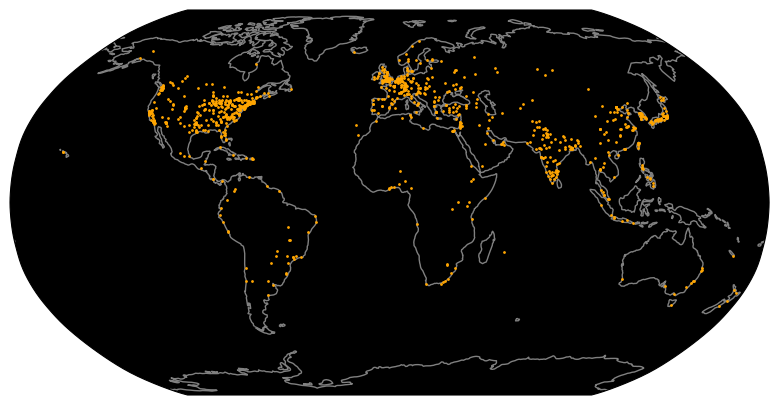

In [28]:


fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_facecolor('black')
# make the map global rather than have it zoom in to
# the extents of any plotted data
ax.set_global()
#ax.stock_img()
ax.coastlines(color='gray')
'''
n=0
for i in C:
    n+=1
    lat,lon=C[i]
    ax.plot(lon,lat, 'o', markersize=50,color='orange',
            transform=ccrs.PlateCarree(),alpha=0.02)
    #if n==1000:
    #    break
    
'''
n=0
for i in C:
    n+=1
    lat,lon=C[i]
    cityName=i.split('|')[0]
    #ax.text(lon,lat,cityName, fontsize=3,color='white',
     #       transform=ccrs.PlateCarree())
    ax.plot(lon,lat, 'o', markersize=1,color='Orange',
            transform=ccrs.PlateCarree())
    if n==1000:
        break
    
plt.show()

# 3. Display connections

In [44]:
i

['599952',
 'ZZ-0004',
 'heliport',
 '(Bogus)Jezero Crater(Location is India not Planet Mars)',
 '18.44',
 '77.45',
 '8530',
 'AF',
 'ZZ',
 'ZZ-U-A',
 '',
 'no',
 'JZRO',
 '',
 '',
 '',
 '',
 '',
 '']

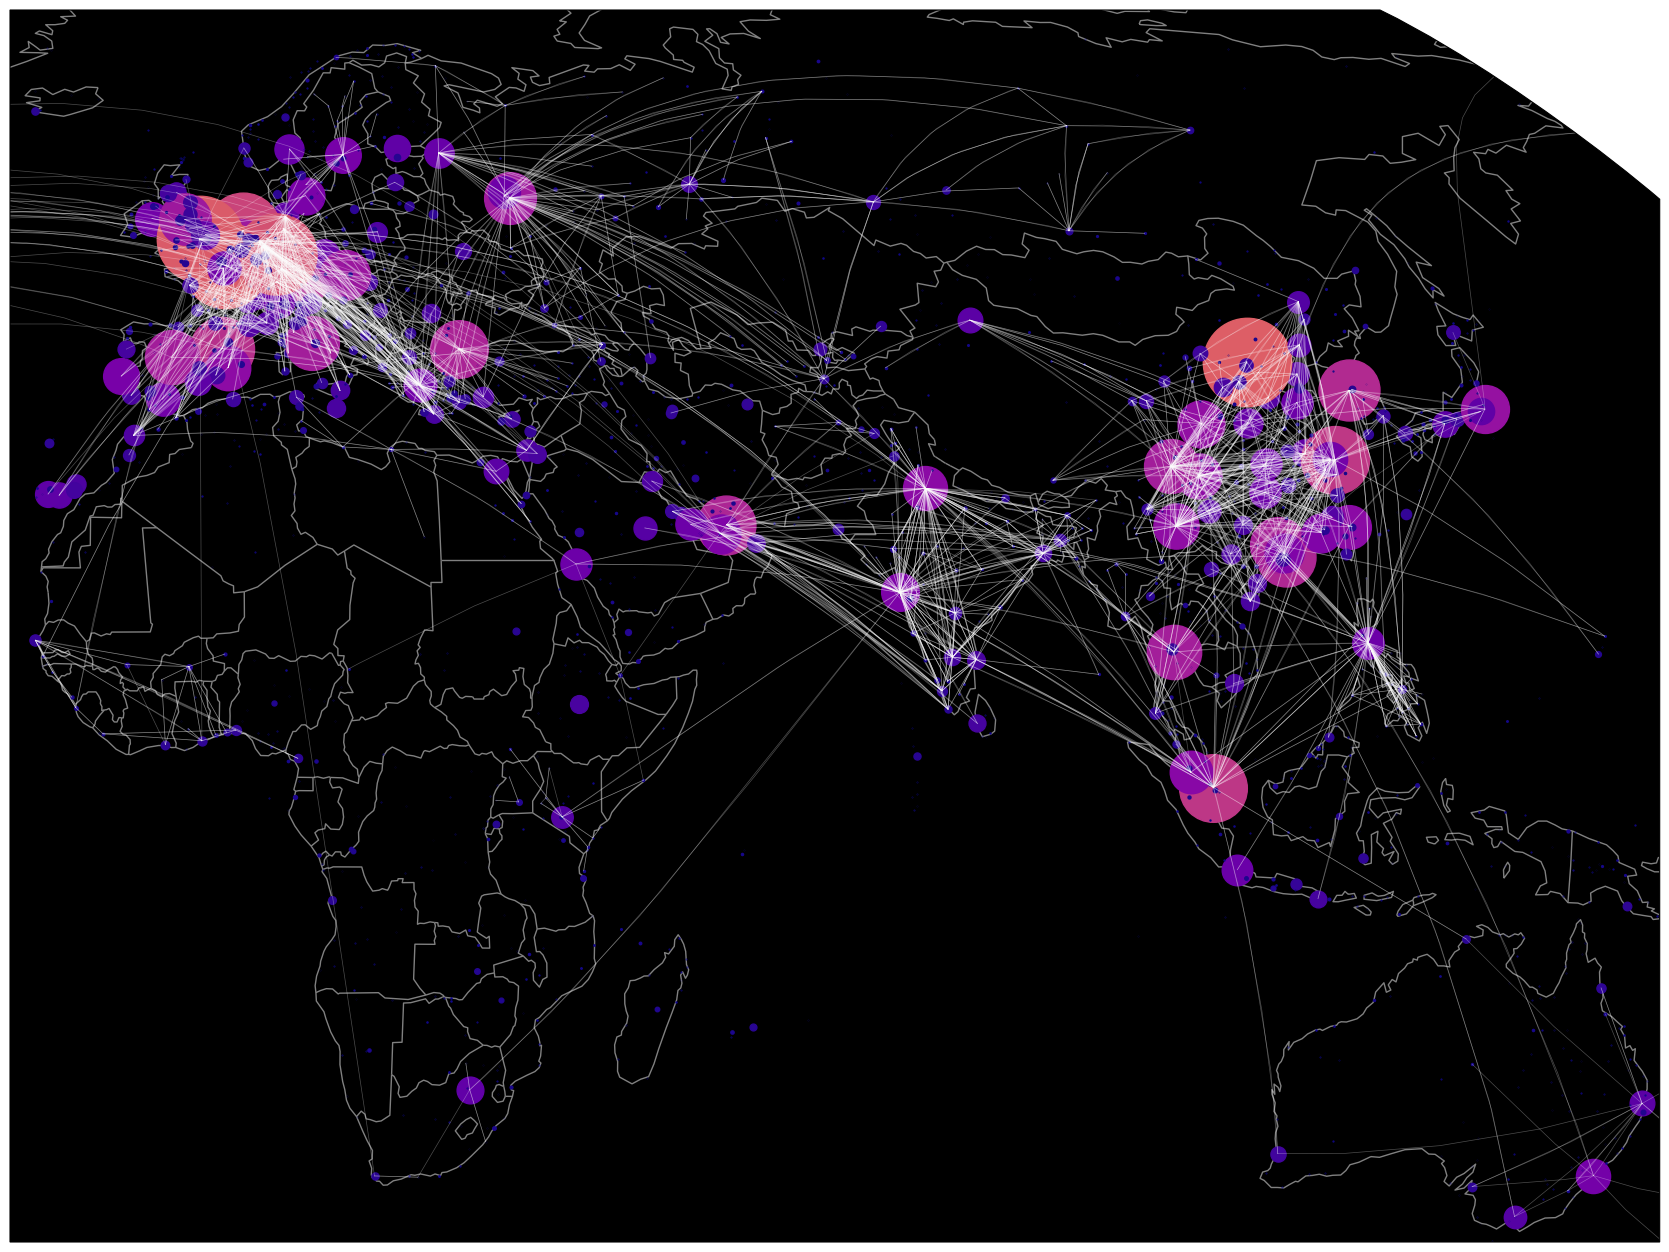

In [40]:
#from cartopy.feature import NaturalEarthFeature
import matplotlib.cm as cm

# populated places (cities)
#places = NaturalEarthFeature(category='cultural', 
                         #     name='populated_places', 
                          #    scale='10m')
fig = plt.figure(figsize=(30, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

#for geom in places.geometries():
  #  ax.plot(*geom.coords[0], 'o', markersize=1, 
   #         transform=ccrs.PlateCarree())


ax.set_facecolor("black")
ax.set_global()
ax.coastlines(color="gray")
ax.set_extent([-20, 150, -40, 75], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='gray')
#ax.set_extent([-25, 45, 30, 75], crs=ccrs.PlateCarree())
# city dots
degree = Counter()
for src_iata, dst_iata in routes:
    degree[src_iata] += 1
    degree[dst_iata] += 1
max_degree = max(degree.values())

# then when plotting nodes, scale markersize by degree
for iata, (lat, lon) in airports.items():
    color = cm.plasma(degree[iata]/ max_degree)
    size = min(degree[iata] * 0.06, 100) # tweak this multiplier to taste
    ax.plot(lon, lat, "o", markersize=size, color=color,
            transform=ccrs.PlateCarree())
for iata, (lat, lon) in airports.items():
    n += 1
    # Uncomment this if you want labels
 #   ax.text(lon, lat, iata, fontsize=3, color="white",
  #           transform=ccrs.PlateCarree())
    #ax.plot(lon, lat, "o", markersize=1, color="orange",
     #       transform=ccrs.PlateCarree())
    if n == 2000:
        break

# edges (connections)
edge_limit = 5000
count = 0

for src_iata, dst_iata in routes:   # ignore the 3rd field
    if src_iata not in airports or dst_iata not in airports:
        continue
    lat1, lon1 = airports[src_iata]
    lat2, lon2 = airports[dst_iata]
    ax.plot([lon1, lon2], [lat1, lat2],
            transform=ccrs.Geodetic(),
            #transform=ccrs.PlateCarree(),
            linewidth=0.5,
            color="white",   # or any color you like
            alpha=0.3)
    
    count += 1
    if count >= edge_limit:
        break



In [22]:
print(routes[:10])

[('AER', 'KZN'), ('ASF', 'KZN'), ('ASF', 'MRV'), ('CEK', 'KZN'), ('CEK', 'OVB'), ('DME', 'KZN'), ('DME', 'NBC'), ('DME', 'TGK'), ('DME', 'UUA'), ('EGO', 'KGD')]
